# ЛР №3. "Обучение с учителем. Задача классификации"

## Импорт

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv')

In [3]:
X = df.drop(columns=['Fire Alarm'])
y = df['Fire Alarm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777, stratify=y)

In [4]:
num_classes = y.nunique()
num_classes

2

Классификация бинарная

## Балансировка классов

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

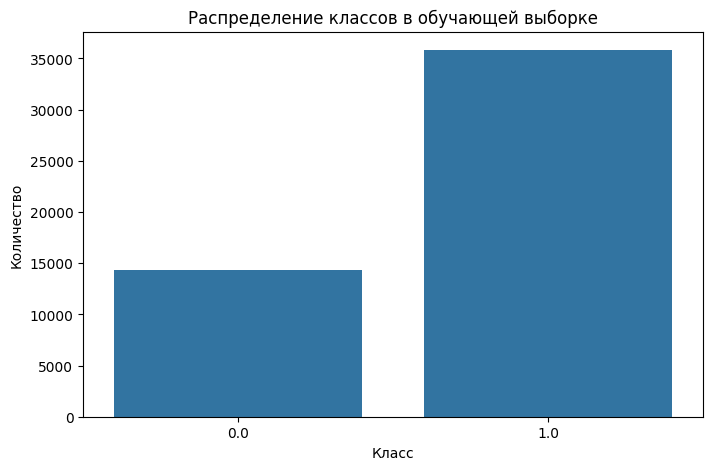

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title('Распределение классов в обучающей выборке')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=777)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"До балансировки: {y_train.value_counts()}")
print(f"После балансировки: {y_train_balanced.value_counts()}")

До балансировки: Fire Alarm
1.0    35806
0.0    14298
Name: count, dtype: int64
После балансировки: Fire Alarm
1.0    35806
0.0    35806
Name: count, dtype: int64


## Обучение моделей

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
    "SVM (RBF Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='rbf'))]),
    "SVM (Sigmoid Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='sigmoid'))]),
    "SVM (Polynomial Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='poly', degree=3))]),
    "SVM (Linear Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='linear'))]),
}

In [9]:
import joblib
import os

preloadModel = True

for name, model in models.items():
    model_path = f'../models/{name}.pkl'
    if preloadModel and os.path.exists(model_path):
        loaded_model = joblib.load(f'../models/{name}.pkl')
        y_pred = loaded_model.predict(X_test)
        print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
        continue

    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    joblib.dump(model, f'../models/{name}.pkl')
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.9835
KNN: 0.9995
Naive Bayes: 0.8202
SVM (RBF Kernel): 0.9995
SVM (Sigmoid Kernel): 0.8023
SVM (Polynomial Kernel): 0.9995
SVM (Linear Kernel): 0.9927


## Подбор гиперпараметров

In [10]:
import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

kf = KFold(n_splits=5, shuffle=True, random_state=777)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Линейная регрессия**

In [11]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10]
}

best_lr = GridSearchCV(models["Logistic Regression"], param_grid_lr, cv=kf, scoring='accuracy')

best_lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr = best_lr.predict(X_test)
accuracy_score(y_test, y_pred_lr)

0.9801213475969982

**KNN**

In [12]:
param_dist_knn = {
    'clf__n_neighbors': range(1, 21),
    'clf__weights': ['uniform', 'distance']
}

best_knn = RandomizedSearchCV(models["KNN"], param_dist_knn, n_iter=10, cv=kf, scoring='accuracy', random_state=777)

best_knn.fit(X_train_balanced, y_train_balanced)
y_pred_knn = best_knn.predict(X_test)
accuracy_score(y_test, y_pred_knn)

0.9996008302730321

**Наивный Байес**

In [13]:
def objective_nb(trial, X, y):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-7, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", GaussianNB(var_smoothing=var_smoothing))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_nb = optuna.create_study(direction="maximize")
study_nb.optimize(lambda trial: objective_nb(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_nb.best_value

[I 2026-04-29 20:15:41,383] A new study created in memory with name: no-name-0f2a3ab6-d276-4133-92d6-45d21d0a7057
[I 2026-04-29 20:15:41,453] Trial 0 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 1.0635822304902172e-09}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-29 20:15:41,506] Trial 1 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 2.7738466960337447e-08}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-29 20:15:41,556] Trial 2 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 8.870163875762265e-10}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-29 20:15:41,608] Trial 3 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 7.876389775004102e-10}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-29 20:15:41,660] Trial 4 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 2.2065437508050254e-10}. Best is trial 0 with 

0.7736972406223082

**SVM RBF**

In [14]:
def objective_svm_rbf(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='rbf', C=c, gamma=gamma))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm_rbf = optuna.create_study(direction="maximize")
study_svm_rbf.optimize(lambda trial: objective_svm_rbf(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm_rbf.best_value

[I 2026-04-29 20:15:41,665] A new study created in memory with name: no-name-87f2ae4b-097a-4bb6-b909-3a6e189850c9
[I 2026-04-29 20:15:47,261] Trial 0 finished with value: 0.9995810709220001 and parameters: {'C': 2.5311961457976575, 'gamma': 'auto'}. Best is trial 0 with value: 0.9995810709220001.
[I 2026-04-29 20:16:07,104] Trial 1 finished with value: 0.9958945246747632 and parameters: {'C': 0.1300162285054096, 'gamma': 'scale'}. Best is trial 0 with value: 0.9995810709220001.
[I 2026-04-29 20:16:24,249] Trial 2 finished with value: 0.9974724727015764 and parameters: {'C': 0.1987854293095015, 'gamma': 'scale'}. Best is trial 0 with value: 0.9995810709220001.
[I 2026-04-29 20:16:40,303] Trial 3 finished with value: 0.9978913978796864 and parameters: {'C': 0.22949822253114804, 'gamma': 'auto'}. Best is trial 0 with value: 0.9995810709220001.
[I 2026-04-29 20:16:45,537] Trial 4 finished with value: 0.9996648581025616 and parameters: {'C': 3.2031963086641095, 'gamma': 'auto'}. Best is tri

0.9996648581025616

**SVM Sigmoid**

In [15]:
def objective_svm_sigmoid(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='sigmoid', C=c, coef0=coef0))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_sigmoid = optuna.create_study(direction="maximize")
study_sigmoid.optimize(lambda trial: objective_svm_sigmoid(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_sigmoid.best_value

[I 2026-04-29 20:16:45,543] A new study created in memory with name: no-name-fdd0ed1c-be30-4246-9e18-3f7b206848f7
[I 2026-04-29 20:17:51,630] Trial 0 finished with value: 0.8119030230414357 and parameters: {'C': 1.2983536519717156, 'coef0': 0.3485705542149481}. Best is trial 0 with value: 0.8119030230414357.
[I 2026-04-29 20:18:54,602] Trial 1 finished with value: 0.796165475362481 and parameters: {'C': 2.0460341177685253, 'coef0': 0.5371909548825137}. Best is trial 0 with value: 0.8119030230414357.
[I 2026-04-29 20:20:00,377] Trial 2 finished with value: 0.7843937148090405 and parameters: {'C': 0.4508546088129875, 'coef0': 0.6517553779639127}. Best is trial 0 with value: 0.8119030230414357.
[I 2026-04-29 20:21:04,144] Trial 3 finished with value: 0.8379740421975672 and parameters: {'C': 7.42706167523871, 'coef0': 0.027638517963333276}. Best is trial 3 with value: 0.8379740421975672.
[I 2026-04-29 20:22:13,944] Trial 4 finished with value: 0.8300144842878951 and parameters: {'C': 2.488

0.8379740421975672

**SVM Polynomial**

In [16]:
def objective_svm_poly(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    degree = trial.suggest_int('degree', 2, 5)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='poly', C=c, degree=degree))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm_poly = optuna.create_study(direction="maximize")
study_svm_poly.optimize(lambda trial: objective_svm_poly(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm_poly.best_value

[I 2026-04-29 20:22:13,950] A new study created in memory with name: no-name-02b3e2ad-5978-4b5a-9b75-2e8cfb13f346
[I 2026-04-29 20:22:52,854] Trial 0 finished with value: 0.9954756121712945 and parameters: {'C': 1.0165977066197986, 'degree': 4}. Best is trial 0 with value: 0.9954756121712945.
[I 2026-04-29 20:23:22,327] Trial 1 finished with value: 0.9994135014357395 and parameters: {'C': 1.833038820748804, 'degree': 4}. Best is trial 1 with value: 0.9994135014357395.
[I 2026-04-29 20:23:58,726] Trial 2 finished with value: 0.9834803996369086 and parameters: {'C': 0.1114312132563552, 'degree': 2}. Best is trial 1 with value: 0.9994135014357395.
[I 2026-04-29 20:25:03,983] Trial 3 finished with value: 0.9148885212137865 and parameters: {'C': 0.45593500647849, 'degree': 5}. Best is trial 1 with value: 0.9994135014357395.
[I 2026-04-29 20:25:21,061] Trial 4 finished with value: 0.996969765217767 and parameters: {'C': 0.7643552772778892, 'degree': 3}. Best is trial 1 with value: 0.99941350

0.9994135014357395

**SVM Linear**

In [17]:
def objective_svm_linear(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='linear', C=c))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(lambda trial: objective_svm_poly(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm.best_value

[I 2026-04-29 20:25:21,066] A new study created in memory with name: no-name-46dc2b76-72e5-471d-a686-b0106d0a303f
[I 2026-04-29 20:26:04,786] Trial 0 finished with value: 0.9866083910046587 and parameters: {'C': 0.7443467124720601, 'degree': 4}. Best is trial 0 with value: 0.9866083910046587.
[I 2026-04-29 20:26:14,213] Trial 1 finished with value: 0.9981148264612937 and parameters: {'C': 2.9741874058087854, 'degree': 3}. Best is trial 1 with value: 0.9981148264612937.
[I 2026-04-29 20:26:22,549] Trial 2 finished with value: 0.9984778993688643 and parameters: {'C': 3.999242589443613, 'degree': 3}. Best is trial 2 with value: 0.9984778993688643.
[I 2026-04-29 20:26:50,682] Trial 3 finished with value: 0.9954337215059311 and parameters: {'C': 7.14603789524917, 'degree': 5}. Best is trial 2 with value: 0.9984778993688643.
[I 2026-04-29 20:27:14,898] Trial 4 finished with value: 0.9978774362745103 and parameters: {'C': 0.37629739739490375, 'degree': 3}. Best is trial 2 with value: 0.998477

0.9984778993688643

## Оценка моделей при помощи метрик классификации

In [18]:
from sklearn.metrics import RocCurveDisplay

**Линейная регрессия**

In [19]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      3575
         1.0       1.00      0.98      0.99      8951

    accuracy                           0.98     12526
   macro avg       0.97      0.98      0.98     12526
weighted avg       0.98      0.98      0.98     12526



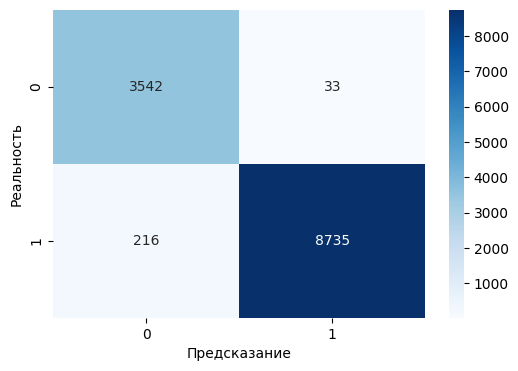

In [20]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

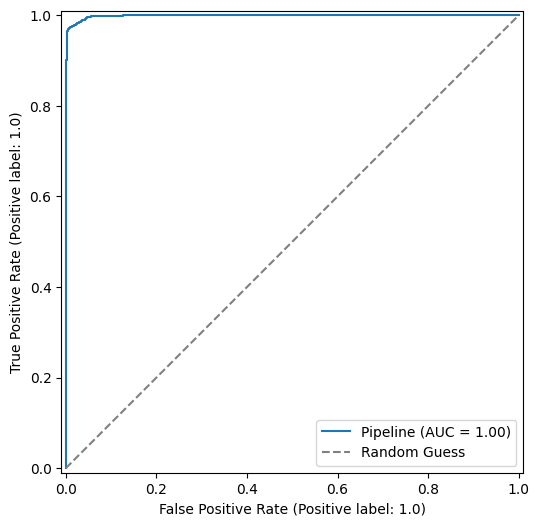

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
models["Logistic Regression"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["Logistic Regression"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**KNN**

In [22]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



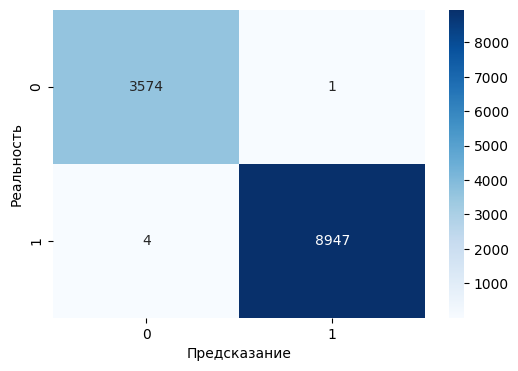

In [23]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

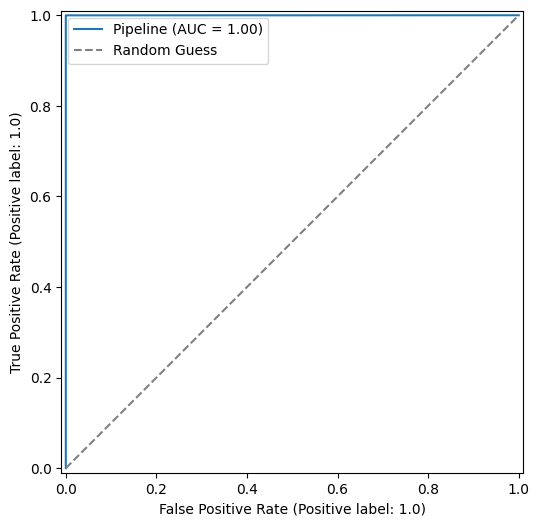

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
models["KNN"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["KNN"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

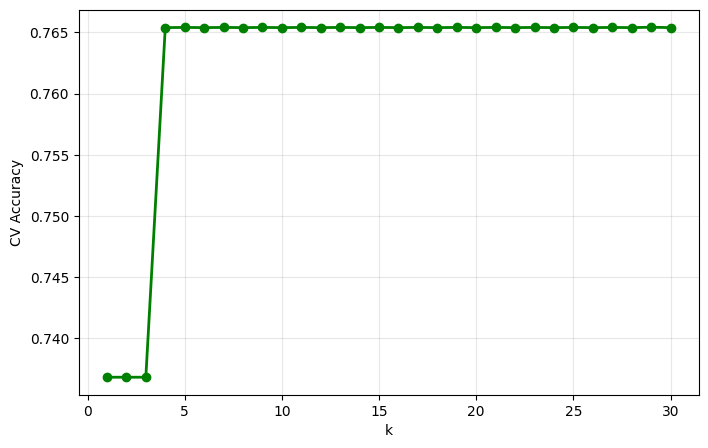

In [25]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o', color='green', linewidth=2)
plt.xlabel('k')
plt.ylabel('CV Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]

**Наивный Байес**

In [26]:
best_params = study_nb.best_params

best_nb = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", GaussianNB(**best_params))
])

best_nb.fit(X_train_balanced, y_train_balanced)

y_pred_nb = best_nb.predict(X_test)

In [27]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         0.0       0.90      0.57      0.70      3575
         1.0       0.85      0.97      0.91      8951

    accuracy                           0.86     12526
   macro avg       0.88      0.77      0.80     12526
weighted avg       0.86      0.86      0.85     12526



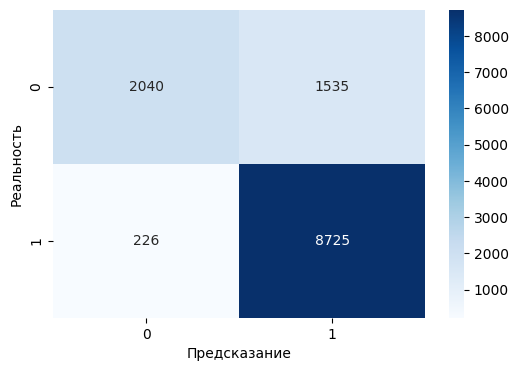

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

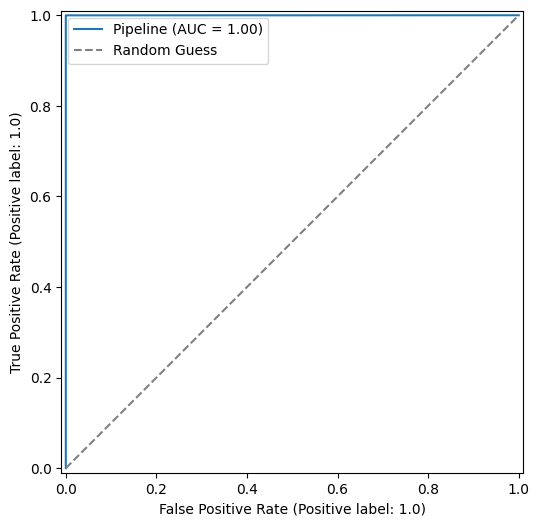

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
models["KNN"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["KNN"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM RBF**

In [30]:
best_params = study_svm_rbf.best_params

best_svm_rbf = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel="rbf",**best_params))
])

best_svm_rbf.fit(X_train_balanced, y_train_balanced)

y_pred_svm_rbf = best_svm_rbf.predict(X_test)

In [31]:
print(classification_report(y_test, y_pred_svm_rbf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



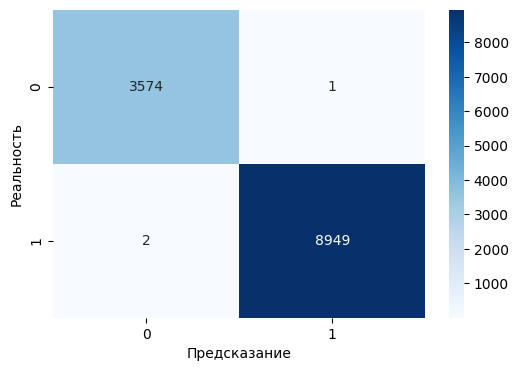

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_rbf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

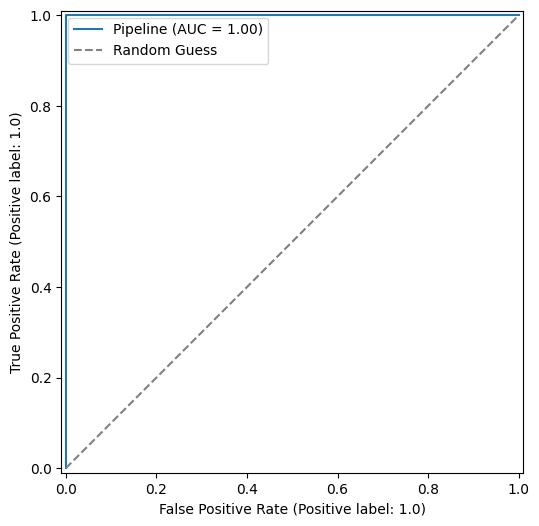

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (RBF Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (RBF Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Sigmoid**

In [34]:
best_params = study_svm_rbf.best_params

best_svm_sigmoid = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel="sigmoid",**best_params))
])

best_svm_sigmoid.fit(X_train_balanced, y_train_balanced)

y_pred_svm_sigmoid = best_svm_sigmoid.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred_svm_sigmoid))

              precision    recall  f1-score   support

         0.0       0.68      0.85      0.75      3575
         1.0       0.93      0.84      0.88      8951

    accuracy                           0.84     12526
   macro avg       0.80      0.84      0.82     12526
weighted avg       0.86      0.84      0.85     12526



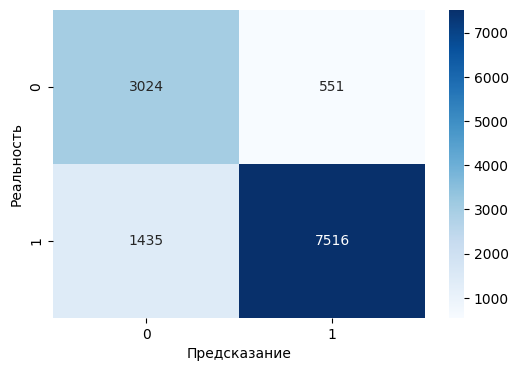

In [36]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_sigmoid), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

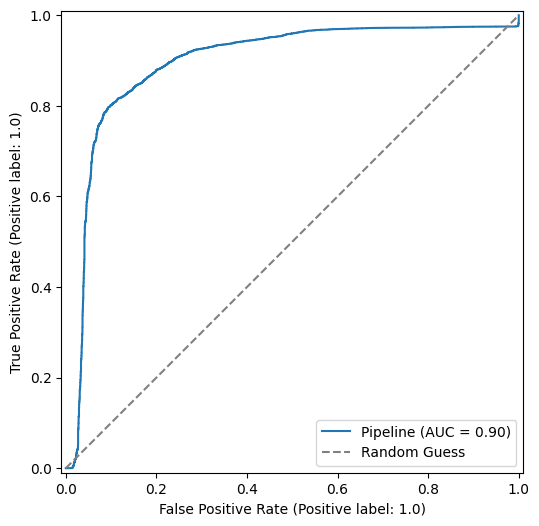

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Sigmoid Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Sigmoid Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Polynomial**

In [38]:
best_params = study_svm_poly.best_params

best_svm_poly = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel='poly',**best_params))
])

best_svm_poly.fit(X_train_balanced, y_train_balanced)

y_pred_svm_poly = best_svm_poly.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred_svm_poly))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



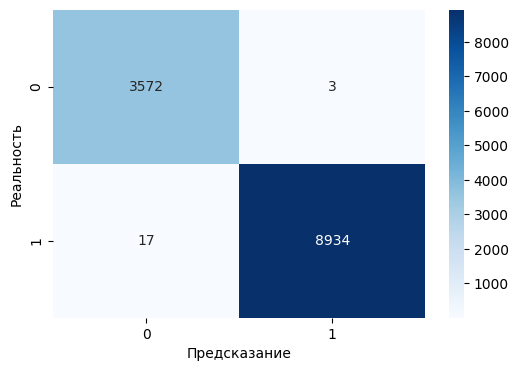

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_poly), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

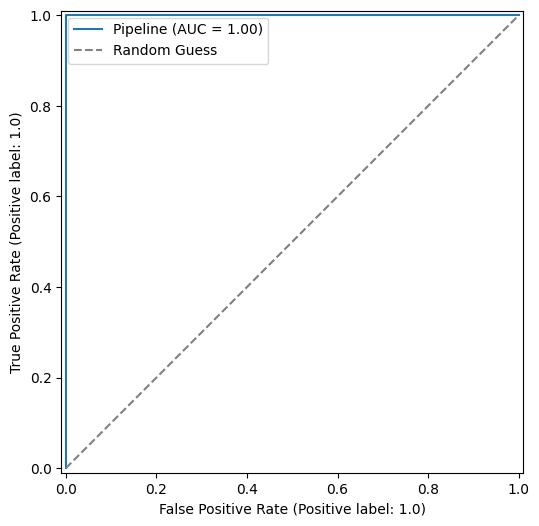

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Polynomial Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Polynomial Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Linear**

In [42]:
best_params = study_svm.best_params

best_svm = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel='linear',**best_params))
])

best_svm.fit(X_train_balanced, y_train_balanced)

y_pred_svm = best_svm.predict(X_test)

In [43]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      3575
         1.0       1.00      0.99      0.99      8951

    accuracy                           0.99     12526
   macro avg       0.98      0.99      0.99     12526
weighted avg       0.99      0.99      0.99     12526



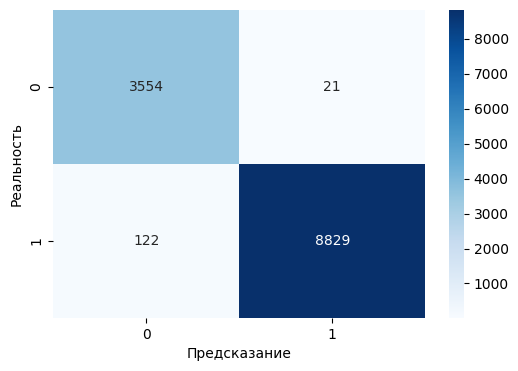

In [44]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

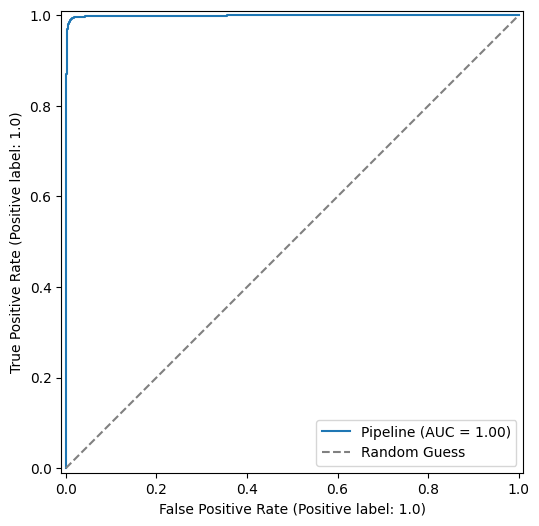

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Linear Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Linear Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

## Реализация метрик

In [46]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score
)

In [47]:
def custom_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

In [48]:
def custom_metrics(y_true, y_pred):
    cm = custom_confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

In [49]:
def custom_roc_auc(y_true, y_prob):
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    
    match = 0
    for p in pos:
        for n in neg:
            if p > n:
                match += 1
            elif p == n:
                match += 0.5
                
    return match / (len(pos) * len(neg))

**Сравнение**

In [50]:
custom_confusion_matrix(y_test, y_pred_knn)

array([[3574,    1],
       [   4, 8947]])

In [51]:
confusion_matrix(y_test, y_pred_knn)

array([[3574,    1],
       [   4, 8947]])

In [52]:
custom_metrics(y_test, y_pred_knn)

(np.float64(0.9996008302730321),
 np.float64(0.9998882431828342),
 np.float64(0.9995531225561389),
 np.float64(0.9997206547851835))

In [53]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn)}")
print(f"Precision: {precision_score(y_test, y_pred_knn)}")
print(f"Recall:    {recall_score(y_test, y_pred_knn)}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn)}")

Accuracy:  0.9996008302730321
Precision: 0.9998882431828342
Recall:    0.9995531225561389
F1-Score:  0.9997206547851836


In [54]:
custom_roc_auc(y_test, y_pred_knn)

0.9996367011382093

In [55]:
print(roc_auc_score(y_test, y_pred_knn))

0.9996367011382093


## Реализация KNN

In [62]:
from custom_knn import CustomKNN

In [63]:
custom_knn = CustomKNN(k=5, metric="manhattan")

In [64]:
custom_knn.fit(X_train_balanced, y_train_balanced)

In [65]:
y_pred = custom_knn.predict(X_test)

In [66]:
custom_confusion_matrix(y_test, y_pred)

array([[3575,    0],
       [   3, 8948]])

In [67]:
custom_metrics(y_test, y_pred)

(np.float64(0.9997604981638193),
 np.float64(1.0),
 np.float64(0.9996648419171043),
 np.float64(0.9998323928711101))

## Вывод

Все модели показали хорошие метрики, особенно KNN и SVM с ядрами RBF и Polynomial. Их точность почти равна 1.

После подбора гиперпараметров результаты лишь немного улучшись, модели по умолчанию были настроены неплохо.

Дольше всего подбирались гиперпараметры для SVM на сигмоиде и полиномиальном ядре, причём сигмоид в итоге выдал относительно слабый результат. Как и Naive Bayes. 

KNN при этом обучался быстро и попал в число лидеров, так что для этой задачи он выглядит самым удачным выбором.